# ConnectaTel Telecom Analysis

ConnectaTel is a telecommunications company operating in Latin America. This analysis examines customer and service usage data recorded through **2024** to assess data quality, clean inconsistencies, analyze customer usage, detect outliers, and segment customers in support of business recommendations.

The analysis uses three datasets:

- **plans.csv**: available plans, prices, included allowances, and additional usage charges.
- **users_latam.csv**: customer information, including age, city, registration date, plan, and churn date.
- **usage.csv**: service activity records for calls and text messages.

The findings inform retention strategies, customer targeting, and potential improvements to ConnectaTel's plans.

## 1. Data Loading and Initial Exploration

The initial review establishes the structure, data types, and completeness of the three datasets before cleaning and aggregation.

### 1.1 Data Loading and Quick Review

The CSV files are loaded from `/datasets/` into `plans`, `users`, and `usage`. The first rows provide an initial view of each dataset.

In [49]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import shutil

In [94]:
# Load source datasets

base_url = "https://raw.githubusercontent.com/mark-savage-da/connectatel-telecom-analysis/portfolio-polish/datasets"

plans = pd.read_csv(f"{base_url}/plans.csv")
users = pd.read_csv(f"{base_url}/users_latam.csv")
usage = pd.read_csv(f"{base_url}/usage.csv")

print("plans:", plans.shape)
print("users:", users.shape)
print("usage:", usage.shape)

plans: (2, 8)
users: (4000, 8)
usage: (40000, 6)


In [51]:

# Preview the first five plan records
plans.head()


,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [52]:
# Preview the first five customer records
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [53]:
# Preview the first five usage records
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


### 1.2 Dataset Structure Review

Dataset dimensions, column types, and non-null counts provide a baseline for the data quality assessment.

In [54]:
# Review dataset dimensions
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [55]:
# Inspect plan structure
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 260.0+ bytes


In [56]:
# Inspect customer structure
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [57]:
# Inspect usage structure
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


## 2. Data Quality Assessment

### 2.1 Missing-Value Review

Missing-value counts and proportions indicate where incomplete data may affect analysis or require treatment. The `plans` dataset contains only 2 rows and has no missing values, so no further missing-value exploration is needed.

In [58]:
# Review missing values in users
print("Missing-value counts")
print(users.isna().sum())

print("\nMissing-value proportions")
print(users.isna().mean())

Missing-value counts
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Missing-value proportions
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [59]:
# Review missing values in usage
print("Missing-value counts")
print(usage.isna().sum())

print("\nMissing-value proportions")
print(usage.isna().mean())

Missing-value counts
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Missing-value proportions
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


**Missing-value assessment**

- `plans` has no observed missing values and does not require additional cleaning.
- In `users`, `city` has 469 missing values (11.7%). These warrant investigation before imputation or removal because they may affect geographic analysis.
- In `users`, `churn_date` has 3534 missing values (88.35%). These likely represent customers who have not canceled service and should be retained as logical absences.
- In `usage`, `date` has 50 missing values (0.125%). This small proportion could be addressed through simple imputation or targeted exclusion if the analysis is unaffected.
- In `usage`, `duration` has 22076 missing values (55.19%). Direct imputation is inappropriate before checking whether these records represent non-call events.
- In `usage`, `length` has 17896 missing values (44.74%). These also require investigation because they may represent non-message events.
- The `id`, `user_id`, and `type` columns in `usage` have no missing values and can be used directly in the analysis.

### 2.2 Invalid and Sentinel Value Detection

Numerical summaries and categorical reviews help identify invalid values, unexpected categories, and sentinels. The `plans` dataset contains only 2 rows and does not require additional exploration here.

In [60]:
# Summarize numerical customer fields
users[['user_id', 'age']].describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- `user_id` is an identifier rather than a business metric; its uniqueness remains relevant to data quality.
- `age` requires review for invalid or out-of-range values.

In [61]:
# Summarize numerical usage fields
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- `id` and `user_id` are identifiers rather than business metrics.
- Numerical fields require review for implausible values, such as negative durations or invalid message lengths.

In [62]:
# Review customer categories
columnas_user = ['city', 'plan']
users[columnas_user].describe()

,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


- `city` identifies recorded customer locations and supports checks for valid categories and spelling inconsistencies.
- `plan` identifies subscribed plans and supports checks for unexpected or inconsistent categories.

In [63]:

# Review usage event categories
usage['type'].describe()


,type
count,40000
unique,2
top,text
freq,22092


- `type` contains the activity categories recorded in `usage`.
- Category validation focuses on expected call and message types and potential inconsistent or unexpected labels.

**Invalid and sentinel value assessment**

- In `users`, `user_id` is an identifier; uniqueness and consistency are relevant, rather than business interpretation.
- `age` requires review for negative, zero, or excessively high values. Invalid values should be flagged and then imputed or excluded depending on their frequency.
- In `usage`, `id` and `user_id` also require consistency checks rather than behavioral interpretation.
- Numerical usage fields require checks for implausible durations or message lengths. Any invalid values should be marked as missing for subsequent cleaning.
- In `users`, spelling errors, inconsistent categories, or unexpected values in `city` should be standardized if found.
- `plan` should contain valid plan categories; unexpected labels should be corrected or flagged.
- In `usage`, unexpected `type` labels should be standardized or the affected records excluded after review.

### 2.3 Date Validation and Standardization

Date fields are converted with invalid entries coerced to missing values. Year frequencies are reviewed against the analysis cutoff of 2024 to identify out-of-range dates.

In [64]:
# Convert customer registration dates
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [65]:
# Convert usage dates
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [66]:
# Review registration years
users['reg_date'].dt.year.value_counts().sort_index()

,count
reg_date,
2022,1314
2023,1316
2024,1330
2026,40


The initial review of `reg_date` considers whether registration years align with the expected analysis period. Future or unusually old dates require closer inspection; the detailed assessment follows below.

In [67]:
# Review usage years
usage['date'].dt.year.value_counts().sort_index()

,count
date,
2024.0,39950


Only 2024 appears in `date`, consistent with the expected analysis period. This column provides the basis for temporal analysis, with no observed out-of-range years.

**Date assessment**

`reg_date` contains 2022, 2023, 2024, and 2026. The year 2026 falls outside the analysis cutoff of 2024. These records warrant investigation and, if confirmed as entry errors, conversion to missing values (`NaT`) or exclusion from the analysis.

`usage['date']` contains only 2024, consistent with the expected period, and provides the basis for temporal analysis.

## 3. Data Cleaning

### 3.1 Sentinel and Invalid-Date Treatment

The `age` sentinel **-999** is replaced with the median calculated without that sentinel. In `city`, `"?"` is replaced with `pd.NA`. Registration dates after 2024 are marked as missing.

In [68]:
# Replace -999 with the median age excluding the sentinel
users['age'] = pd.to_numeric(users['age'], errors='coerce')
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verify the updated values
users['age'].describe()

,age
count,4000.000000
mean,48.136000
std,17.689919
min,18.000000
25%,33.000000
50%,48.000000
75%,63.000000
max,79.000000


In [69]:

users['city'] = users['city'].replace('?', pd.NA)

# Verify the updated values
users['city'].value_counts(dropna=False)



,count
city,
Bogotá,808
CDMX,730
Medellín,616
NaN,469
GDL,450
Cali,424
MTY,407
<NA>,96


In [70]:
# Mark registration dates after 2024 as missing
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verify the updated values
users['reg_date'].dt.year.value_counts(dropna=False).sort_index()


,count
reg_date,
2022.0,1314
2023.0,1316
2024.0,1330
NaN,40


### 3.2 Missing-Value Treatment

Missing-value proportions in `duration` and `length` are examined by event `type` to distinguish logical absences from values requiring imputation.

In [71]:
# Review duration missingness by event type
usage.groupby('type')['duration'].apply(lambda x: x.isna().mean())

,duration
type,
call,0.000000
text,0.999276


In [72]:
# Review message-length missingness by event type
usage.groupby('type')['length'].apply(lambda x: x.isna().mean())

,length
type,
call,0.99933
text,0.00000


**Missing values in `duration` and `length`**

Missingness depends on `type` and does not appear to reflect random entry errors. Duration is applicable to one activity type, while message length is applicable to the other.

These values are retained as missing because they represent logical absences rather than information that should be imputed.

## 4. User-Level Usage Analysis

### 4.1 Aggregation by Usage Behavior

Key variables from `usage` were summarized by `user_id` to represent each user's historical usage.

1. `usage` was aggregated by `user_id` to include:
   - total number of messages
   - total number of calls
   - total call minutes

2. The resulting columns were renamed as:
   - `cant_mensajes`
   - `cant_llamadas`
   - `cant_minutos_llamada`

3. The resulting table was merged with `users`.

In [73]:


# Create auxiliary event indicators
usage["is_text"] = (usage["type"] == "text").astype(int)  # Count text messages
usage["is_call"] = (usage["type"] == "call").astype(int)  # Count calls

# Aggregate usage by customer
usage_agg = usage.groupby("user_id").agg(
    cant_mensajes=("is_text", "sum"),
    cant_llamadas=("is_call", "sum"),
    cant_minutos_llamada=("duration", "sum")
).reset_index()

# Preview the result
usage_agg.head(3)



,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [74]:
# Rename aggregate columns
usage_agg.columns = ['user_id', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
# Preview the result
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [75]:
# Merge usage aggregates with customer records
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 User-Level Summary Statistics for 2024

Descriptive statistics summarize the ranges, central tendency, and dispersion of numerical customer and usage variables. Percentage shares describe the distribution of customers by `plan`.

In [76]:
# Summarize numerical customer and usage fields
user_profile[['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe()


,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [77]:
# Calculate the percentage of customers by plan
user_profile['plan'].value_counts(normalize=True) * 100

,proportion
plan,
Basico,64.875
Premium,35.125


- Numerical summaries describe the range, central tendency, and dispersion of user-level usage.
- Percentage shares for `plan` show the balance between Basic and Premium customers.

## 5. Distribution and Outlier Analysis

### 5.1 Distribution Analysis

Histograms compare age, message counts, call counts, and total call minutes by plan. Distribution shapes highlight typical behavior, potential differences between plans, and unusually high usage.

In [78]:

# Import analysis libraries


import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


usage["is_text"] = (usage["type"] == "text").astype(int)
usage["is_call"] = (usage["type"] == "call").astype(int)

usage_agg = usage.groupby("user_id").agg(
    cant_mensajes=("is_text", "sum"),
    cant_llamadas=("is_call", "sum"),
    cant_minutos_llamada=("duration", "sum")
).reset_index()

user_profile = users.merge(usage_agg, on="user_id", how="left")

user_profile[["cant_mensajes", "cant_llamadas", "cant_minutos_llamada"]] = user_profile[
    ["cant_mensajes", "cant_llamadas", "cant_minutos_llamada"]
].fillna(0)

user_profile.head()



,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


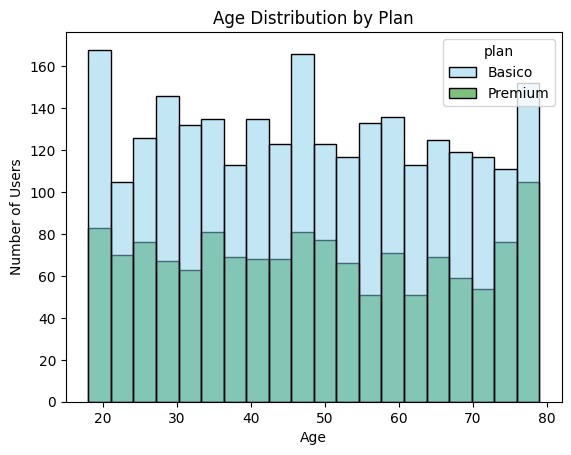

In [79]:

# Plot age distribution by plan

sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue', 'green'], bins=20)
plt.title('Age Distribution by Plan')
plt.xlabel('Age')
plt.ylabel('Number of Users')
plt.show()

**Insight:** The age distribution is slightly right-skewed. There is no pronounced difference between plans, although concentration within specific age ranges warrants further review.

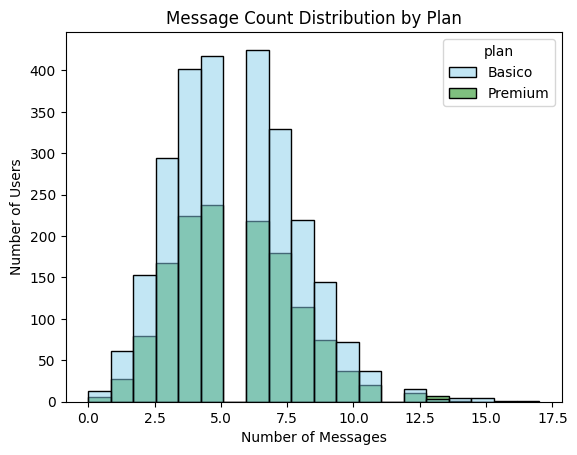

In [80]:
# Plot message count distribution by plan
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue', 'green'], bins=20)
plt.title('Message Count Distribution by Plan')
plt.xlabel('Number of Messages')
plt.ylabel('Number of Users')
plt.show()


**Insight:** The message distribution is right-skewed. Most users send relatively few messages, while a smaller group records higher volumes. Whether Premium includes more high-usage customers warrants further review.

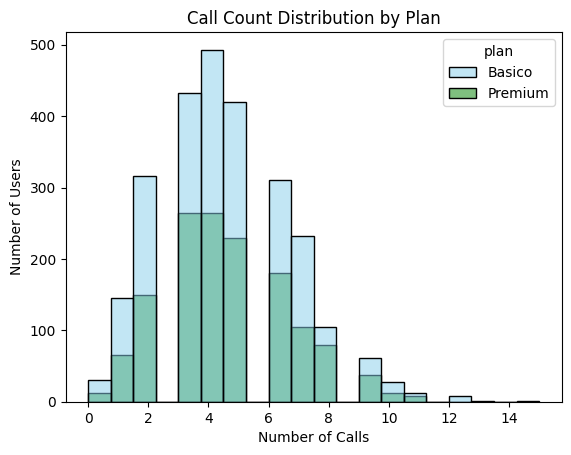

In [81]:

# Plot call count distribution by plan
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue', 'green'], bins=20)
plt.title('Call Count Distribution by Plan')
plt.xlabel('Number of Calls')
plt.ylabel('Number of Users')
plt.show()


**Insight:** Call counts are right-skewed. Most users make relatively few calls, while some record much higher usage. This may suggest behavioral differences by plan.

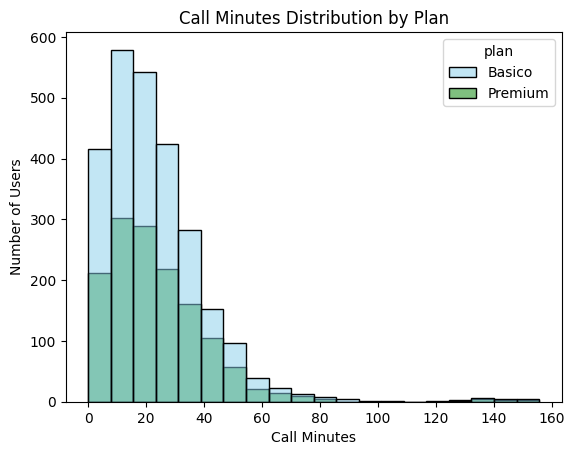

In [82]:


# Plot total call minutes by plan
sns.histplot(
    data=user_profile,
    x='cant_minutos_llamada',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=20
)
plt.title('Call Minutes Distribution by Plan')
plt.xlabel('Call Minutes')
plt.ylabel('Number of Users')
plt.show()

**Insight:** Total call minutes are right-skewed. Most users accumulate relatively few minutes, while a small group records high consumption, suggesting intensive users and potential outliers.

### 5.2 Outlier Detection

Boxplots review `age`, `cant_mensajes`, `cant_llamadas`, and `cant_minutos_llamada`. The interquartile range (IQR) method identifies values outside the lower and upper bounds for further assessment.

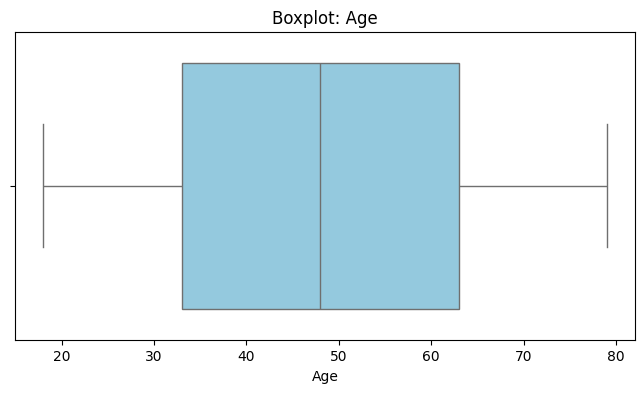

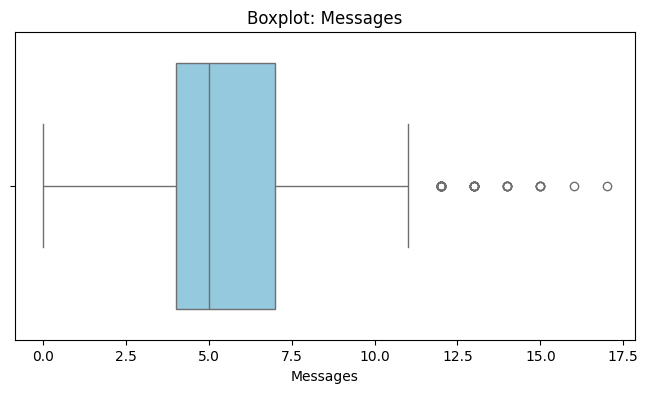

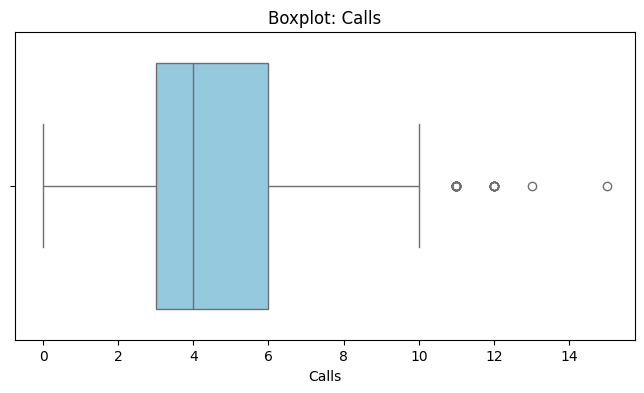

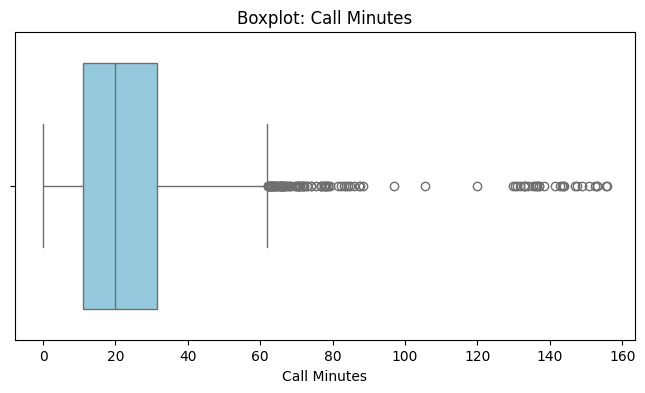

age: no outliers detected

cant_mensajes: outliers detected
Lower bound: -0.5
Upper bound: 11.5
Number of outliers: 46

cant_llamadas: outliers detected
Lower bound: -1.5
Upper bound: 10.5
Number of outliers: 30

cant_minutos_llamada: outliers detected
Lower bound: -19.35
Upper bound: 61.870000000000005
Number of outliers: 109



In [93]:
# Review numerical distributions with boxplots
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
labels = {'age': 'Age', 'cant_mensajes': 'Messages', 'cant_llamadas': 'Calls', 'cant_minutos_llamada': 'Call Minutes'}

for col in columnas_numericas:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=user_profile[col], color='skyblue')
    plt.title(f"Boxplot: {labels[col]}")
    plt.xlabel(labels[col])
    plt.show()

# Calculate IQR bounds
for col in columnas_numericas:
    q1 = user_profile[col].quantile(0.25)
    q3 = user_profile[col].quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    outliers = user_profile[
        (user_profile[col] < limite_inferior) | (user_profile[col] > limite_superior)
    ]

    if len(outliers) > 0:
        print(f'{col}: outliers detected')
        print(f'Lower bound: {limite_inferior}')
        print(f'Upper bound: {limite_superior}')
        print(f'Number of outliers: {len(outliers)}')
        print()
    else:
        print(f'{col}: no outliers detected')
        print()


**Outlier assessment**

- `age` contains outliers, but the calculated bounds do not suggest impossible ages from a business perspective. These values warrant review rather than automatic removal.
- `cant_mensajes` contains outliers: a small group sends substantially more messages than most users, consistent with a right-skewed distribution.
- `cant_llamadas` contains outliers because some users make considerably more calls than typical; this distribution is also right-skewed.
- `cant_minutos_llamada` has the largest number of outliers, indicating users with substantially higher minute consumption. These values warrant review because they may strongly influence means and comparisons.

In [84]:
# Calculate IQR bounds
columnas_limites = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    q1 = user_profile[col].quantile(0.25)
    q3 = user_profile[col].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    print(f'{col}:')
    print(f'Lower bound: {limite_inferior}')
    print(f'Upper bound: {limite_superior}')
    print()


age:
Lower bound: -12.0
Upper bound: 108.0

cant_mensajes:
Lower bound: -0.5
Upper bound: 11.5

cant_llamadas:
Lower bound: -1.5
Upper bound: 10.5

cant_minutos_llamada:
Lower bound: -19.35
Upper bound: 61.870000000000005



In [85]:
# Compare upper bounds and maxima to assess outlier retention
user_profile[columnas_limites].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,4000.000000,4000.000000
mean,48.136000,5.523000,4.477000,23.311225
std,17.689919,2.359738,2.145139,18.169564
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.107500
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.412500
max,79.000000,17.000000,15.000000,155.690000


## 6. Customer Segmentation

### 6.1 Usage-Based Segmentation

The `grupo_uso` column classifies users by call and message counts:

- **Low usage**: fewer than 5 calls and fewer than 5 messages.
- **Medium usage**: fewer than 10 calls and fewer than 10 messages, after excluding low-usage users.
- **High usage**: all remaining users.

The existing category values are retained in the implementation.

In [86]:
# Create the usage segment column
import numpy as np

user_profile['grupo_uso'] = np.where(
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    'Bajo uso',
    np.where(
        (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10),
        'Uso medio',
        'Alto uso'
    )
)

user_profile[['user_id', 'cant_mensajes', 'cant_llamadas', 'grupo_uso']].head()

,user_id,cant_mensajes,cant_llamadas,grupo_uso
0,10000,7.0,3.0,Uso medio
1,10001,5.0,10.0,Alto uso
2,10002,5.0,2.0,Uso medio
3,10003,11.0,3.0,Alto uso
4,10004,4.0,3.0,Bajo uso


In [87]:
# Verify the updated values
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Age-Based Segmentation

The `grupo_edad` column groups users by age:

- **Young**: under 30.
- **Adult**: 30 to under 60.
- **Older adult**: 60 and above.

The existing category values are retained in the implementation.

In [88]:
# Create the age segment column
user_profile['grupo_edad'] = np.where(
    user_profile['age'] < 30,
    'Joven',
    np.where(
        user_profile['age'] < 60,
        'Adulto',
        'Adulto Mayor'
    )
)

user_profile[['user_id', 'age', 'grupo_edad']].head()

,user_id,age,grupo_edad
0,10000,38,Adulto
1,10001,53,Adulto
2,10002,57,Adulto
3,10003,69,Adulto Mayor
4,10004,63,Adulto Mayor


In [89]:
# Verify the updated values
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Segment Distribution

Count plots show the customer distribution across `grupo_uso` and `grupo_edad`.

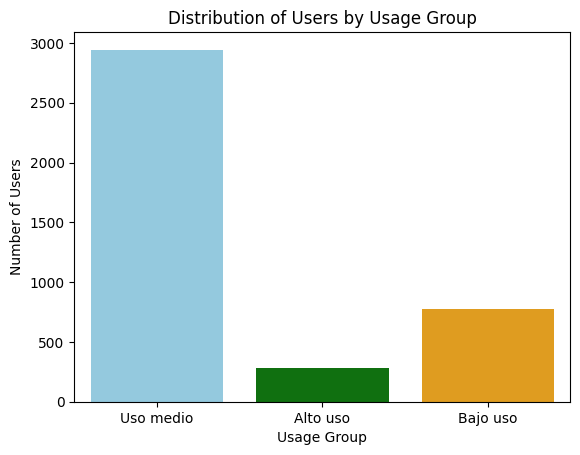

In [90]:
# Plot customer counts by usage segment
sns.countplot(data=user_profile, x='grupo_uso', hue='grupo_uso', palette=['skyblue', 'green', 'orange'], legend=False)
plt.title('Distribution of Users by Usage Group')
plt.xlabel('Usage Group')
plt.ylabel('Number of Users')
plt.show()

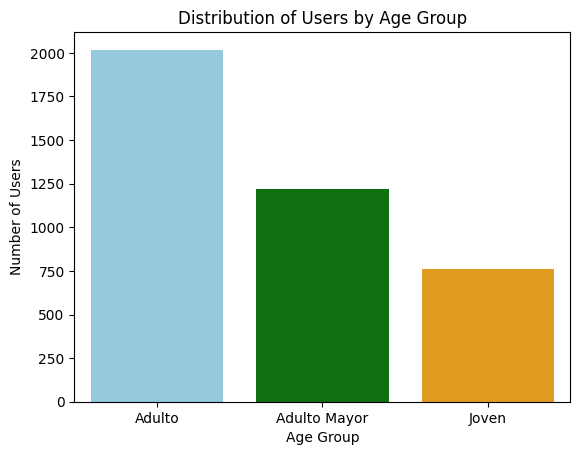

In [91]:
# Plot customer counts by age segment
sns.countplot(data=user_profile, x='grupo_edad', hue='grupo_edad', palette=['skyblue', 'green', 'orange'], legend=False)
plt.title('Distribution of Users by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Users')
plt.show()


## 7. Executive Insights and Business Recommendations

**Data quality**

The original data contained missing values, sentinels, and out-of-range dates. In `users`, `city` had 469 missing values (11.7%) and `churn_date` had 3534 (88.35%). In `usage`, `date` had 50 missing values (0.125%), `duration` had 22076 (55.19%), and `length` had 17896 (44.74%). The data also contained the `age` sentinel -999, the invalid `city` value "?", and 40 `reg_date` records dated 2026, outside the analysis period.

**Customer segments**

Customers were segmented by usage (low, medium, and high) and age (young, adult, and older adult). Low-usage customers make few calls and send few messages; medium-usage customers show moderate activity; high-usage customers account for greater call, message, and minute consumption. Adults and older adults predominate, while younger customers appear to be a smaller group.

**Commercial opportunities**

High-usage customers appear to be the most valuable segment because they consume more calls, messages, and minutes. They offer opportunities for revenue, retention, and migration to more comprehensive plans. Intensive users still on Basic plans are particularly relevant candidates for upselling.

**Extreme usage patterns**

Outliers occur in `age`, `cant_mensajes`, `cant_llamadas`, and `cant_minutos_llamada`. Age outliers do not appear implausible from a business perspective. Usage outliers, especially total call minutes, occur in the upper tail and indicate intensive users. These customers consume substantially more than average and can inflate means if results are interpreted without care.

**Business recommendations**

- Offer high-usage customers plans with greater allowances and targeted upselling campaigns.
- Maintain simple, affordable options for low-usage customers.
- Tailor campaigns by age, recognizing that young, adult, and older customers may have different needs.
- Continue monitoring data quality to reduce decisions based on entry errors or invalid values.
- Consider new plans or add-ons for intensive users with high call and message demand.

**Additional implications**

- Most missing `churn_date` values appear to represent customers who have not canceled, rather than entry errors. Missing `duration` and `length` values depend on event `type`, represent logical absences, and were not imputed.
- Adults form the largest age segment, followed by older adults and then younger customers. This relatively mature customer base creates opportunities for offers tailored to life stage. The smaller young segment may be attractive for simple or entry-level plans.
- Median call and message counts suggest that the typical customer falls between low and medium usage, while a smaller group records much higher consumption. This heterogeneity supports differentiated offers.
- Age outliers were not removed automatically. High message and call counts reflect more intensive behavior, and total call minutes contain the largest number of outliers. These values appear to represent real behavior rather than entry errors and should be retained with attention to their effect on means and comparisons.

Together, these findings suggest a heterogeneous customer base: a majority with low or medium usage and a smaller group of intensive users. This creates opportunities for commercial segmentation and plan optimization.